When training neural networks, one big problem is **overfitting**.
The model memorizes the training data but performs poorly on new data.

To solve this, we use **regularization techniques** like:

1. **L1 / L2 Regularization**
2. **Dropout**
3. **Batch Normalization**

I'll explain them **visually and conceptually**.

---

# 1. What is Overfitting? (Why Regularization is Needed)

![Image](https://images.openai.com/static-rsc-3/0PdrXmtVApFIjm6PHot54M2BqiJiMebBtJTciMQvphiVX1fa7pIkufQZ7dcpaSk2ribDTHNBJDI3O0USuwJh18mrTrdnqBRLk3nmHpVVNWM?purpose=fullsize\&v=1)

![Image](https://codingnomads.com/images/f8c470c9-c714-48e6-0397-7a9a4e57b500/public)

![Image](https://images.openai.com/static-rsc-3/ctwE7UEz6KYzHi11mg7hdg4BJK39tgPkzLQPxZhL1MFI-cLv6p32nCbzDk1NCItPas1Hl_W4q-QA-iJ54o8Q7DFCmld8Yqmlvoab5MS3ptA?purpose=fullsize\&v=1)

![Image](https://images.openai.com/static-rsc-3/t-CzyKcbv3OaveOH7aZrirv9MJsvIpDSMkTe9Q0RAaE0p6VXXobjTKWC6t-auEK7S2mIpOzJ7tiVflqsXguerE0NG0C7ff_mZw5jE2vq6x0?purpose=fullsize\&v=1)

Three situations occur when training a model:

| Case         | Meaning                |
| ------------ | ---------------------- |
| Underfitting | Model too simple       |
| Good Fit     | Model generalizes well |
| Overfitting  | Model memorizes data   |

Example:

If we fit a **very complex polynomial**, it will pass through **every training point**, but fail on new data.

Regularization **forces the model to stay simple**.

---

# 2. L1 and L2 Regularization

### Idea

Add a **penalty to large weights** in the loss function.

Instead of minimizing just loss:

[
Loss
]

we minimize

[
Loss + Regularization
]

---

## L2 Regularization (Weight Decay)

Regularization term:

[
\lambda \sum w^2
]

Where

* **λ (lambda)** = regularization strength
* **w** = weights

Total loss becomes

[
Loss = OriginalLoss + \lambda \sum w^2
]

Effect:

* Penalizes **large weights**
* Makes weights **smaller and smoother**

Visual idea:

Large weights → complicated curve
Small weights → smoother curve

---

## L1 Regularization

Regularization term:

[
\lambda \sum |w|
]

Effect:

* Pushes some weights to **exactly zero**
* Performs **feature selection**

Example:

If a feature is useless → weight becomes **0**.

---

### L1 vs L2

| Feature           | L1   | L2          |
| ----------------- | ---- | ----------- |
| Weight shrinkage  | Yes  | Yes         |
| Feature selection | Yes  | No          |
| Sparse model      | Yes  | No          |
| Common usage      | Less | Very common |

---

# 3. Dropout (Very Powerful Regularization)

![Image](https://substackcdn.com/image/fetch/%24s_%21RTwG%21%2Cf_auto%2Cq_auto%3Agood%2Cfl_progressive%3Asteep/https%3A%2F%2Fsubstack-post-media.s3.amazonaws.com%2Fpublic%2Fimages%2F67fd4e25-6c1a-4d4a-9070-181c3c65d34a_3197x1440.png)

![Image](https://www.mdpi.com/electronics/electronics-12-03106/article_deploy/html/images/electronics-12-03106-g001.png)

![Image](https://images.openai.com/static-rsc-3/SxCkRcBo_qRfog5C0rEIWFEqkpv9OUOitxlo5bplrTHNs55h8CijHwcyJ4UtxXVbkXKB5QwWix_AMV1O6U_fag2RgOYuEdSTycmtMPIZ51k?purpose=fullsize\&v=1)

![Image](https://miro.medium.com/0%2ARmEZtV9-NBjaG5BJ.png)

### Idea

During training, **random neurons are turned OFF**.

Example:

Normal network:

```
Input → Hidden → Output
```

With dropout:

Some neurons randomly disappear.

```
Input → Hidden (some neurons removed) → Output
```

Example with 50% dropout:

```
Neuron1  ✓
Neuron2  ✗
Neuron3  ✓
Neuron4  ✗
```

---

### Why Dropout Works

Without dropout:

A neuron may depend heavily on another neuron.

With dropout:

Network must **learn redundant representations**.

So the model becomes **robust**.

---

### Mathematical View

During training:

[
h = f(Wx)
]

With dropout:

[
h = mask * f(Wx)
]

where mask randomly drops neurons.

---

### In TensorFlow

```python
model = tf.keras.Sequential([
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])
```

`0.5` → 50% neurons dropped.

---

# 4. Batch Normalization

![Image](https://miro.medium.com/1%2A0jFN7UvmVxA7jAKZgU3GPg.png)

![Image](https://miro.medium.com/0%2AzLv-ulihIiI4Z-zG.png)

![Image](https://miro.medium.com/v2/resize%3Afit%3A1400/1%2A1NfwjqRqecBcmYWEGkyXbA.png)

![Image](https://media.licdn.com/dms/image/v2/D5612AQH7o8A9lzePZQ/article-cover_image-shrink_600_2000/article-cover_image-shrink_600_2000/0/1713289223417?e=2147483647\&t=MuW9XZ-u1ZVhe4Fg3CzFBi_XHt9c4OausoBJlm4gKnE\&v=beta)

### Problem in Deep Networks

During training, the **distribution of activations changes**.

This is called

**Internal Covariate Shift**

Example:

Layer outputs may change from

```
mean = 0.5
```

to

```
mean = 5
```

This slows training.

---

### Solution: Normalize Activations

Batch normalization makes the output:

```
mean = 0
variance = 1
```

---

### Formula

First normalize:

[
\hat{x} = \frac{x - \mu}{\sqrt{\sigma^2 + \epsilon}}
]

Then scale and shift:

[
y = \gamma \hat{x} + \beta
]

Where

* μ = batch mean
* σ = batch variance
* γ = scale
* β = shift

---

### Benefits

| Benefit               | Explanation                  |
| --------------------- | ---------------------------- |
| Faster training       | Stable gradients             |
| Higher learning rate  | Training becomes stable      |
| Regularization effect | Slightly reduces overfitting |

---

### In TensorFlow

```python
model = tf.keras.Sequential([
    Dense(128),
    BatchNormalization(),
    Activation('relu'),
    Dense(10, activation='softmax')
])
```

---

# 5. Comparison of All Techniques

| Method              | Purpose                   | Where Applied  |
| ------------------- | ------------------------- | -------------- |
| L1 Regularization   | Feature selection         | Loss function  |
| L2 Regularization   | Prevent large weights     | Loss function  |
| Dropout             | Prevent neuron dependency | Hidden layers  |
| Batch Normalization | Stabilize training        | Between layers |

---

# 6. How They Work Together (Real Models)

Typical deep network:

```
Input
   ↓
Dense
   ↓
BatchNorm
   ↓
ReLU
   ↓
Dropout
   ↓
Dense
   ↓
Output
```

BatchNorm → stabilizes training
Dropout → prevents overfitting

---

# 7. Intuition (Easy Way to Remember)

| Technique | Analogy                                      |
| --------- | -------------------------------------------- |
| L2        | Punish large weights                         |
| L1        | Remove useless features                      |
| Dropout   | Randomly remove team members during training |
| BatchNorm | Keep data distribution stable                |

---

If you'd like, I can also explain **one extremely important interview concept next**:

**Why Dropout is NOT used during inference (testing) but only during training** — this is a **very common deep learning interview question.**



# Dropouts
<div class="text_component" data-testid="text-component"><p dir="ltr">The previous segment, you explored different parts of the training process and got some insights on how to judge whether the trained model is performing well (overfitting or underfitting). Neural networks that are&nbsp;usually large, complex models with tens of thousands of parameters have a tendency to overfit the training data.&nbsp;As with many other ML models, <strong>regularisation</strong> is a common technique used in neural networks to address this problem. Let's now take a look at a popular regularisation technique used for neural networks called <strong>dropouts</strong>.&nbsp;</p><p dir="ltr">&nbsp;</p><p dir="ltr">The&nbsp;main purpose of using dropouts is to <strong>reduce overfitting</strong>. Sometimes, a model trains on the training data set and its weights and biases converge to very specific values, values that are ideal for only the training data set. Adding a dropout layer to the neural network helps to break that specific combination of weights and biases. This enables the neural network to search for a broader and more general pattern and makes predictions more robust. In the next video, you will be introduced to the mathematics behind the dropout layer.</p></div>

<div class="MuiBox-root css-1bi8ut6"><div class="text_component" data-testid="text-component"><p>To summarise, the dropout operation is performed by&nbsp;multiplying the weight matrix <img alt="Equation" data-latex="W^l" src="https://latex.upgrad.com/render?formula=W%5El" style="vertical-align: middle;display: inline;">&nbsp;with an <img alt="Equation" data-latex="\alpha" src="https://latex.upgrad.com/render?formula=%5Calpha" style="vertical-align: middle;display: inline;">&nbsp;<strong>mask vector</strong> as shown below.</p><p style="text-align: center;"><img alt="Equation" data-latex="W^l.{\alpha}" src="https://latex.upgrad.com/render?formula=W%5El.%7B%5Calpha%7D" style="vertical-align: middle;display: inline;"></p><p>For e.g. let's consider a weight matrix of the first layer&nbsp;<img alt="Equation" data-latex="W^1 =" src="https://latex.upgrad.com/render?formula=W%5E1%20%3D" style="vertical-align: middle;display: inline;"><img alt="Equation" data-latex="\begin{bmatrix} w^1_{11} &amp; w^1_{12} &amp; w^1_{13}\\ w^1_{21} &amp; w^1_{22} &amp; w^1_{23}\\ w^1_{31} &amp; w^1_{32} &amp; w^1_{33}\\ w^1_{41} &amp; w^1_{42} &amp; w^1_{43}\\ \end{bmatrix}" src="https://latex.upgrad.com/render?formula=%5Cbegin%7Bbmatrix%7D%20w%5E1_%7B11%7D%20%26%20w%5E1_%7B12%7D%20%26%20w%5E1_%7B13%7D%5C%5C%20w%5E1_%7B21%7D%20%26%20w%5E1_%7B22%7D%20%26%20w%5E1_%7B23%7D%5C%5C%20w%5E1_%7B31%7D%20%26%20w%5E1_%7B32%7D%20%26%20w%5E1_%7B33%7D%5C%5C%20w%5E1_%7B41%7D%20%26%20w%5E1_%7B42%7D%20%26%20w%5E1_%7B43%7D%5C%5C%20%5Cend%7Bbmatrix%7D" style="vertical-align: middle;display: inline;"><br>&nbsp;</p><p>Then, the shape of the vector&nbsp;<img alt="Equation" data-latex="\alpha" src="https://latex.upgrad.com/render?formula=%5Calpha" style="vertical-align: middle;display: inline;">&nbsp;will be (3,1). Now if the value of <img alt="Equation" data-latex="q" src="https://latex.upgrad.com/render?formula=q" style="vertical-align: middle;display: inline;">&nbsp;(the probability of 1)&nbsp;is 0.66, the&nbsp;<img alt="Equation" data-latex="\alpha" src="https://latex.upgrad.com/render?formula=%5Calpha" style="vertical-align: middle;display: inline;">&nbsp;vector will have two 1s and one 0. Hence, the&nbsp;<img alt="Equation" data-latex="\alpha" src="https://latex.upgrad.com/render?formula=%5Calpha" style="vertical-align: middle;display: inline;">&nbsp;vector can be any of the following three:</p><p style="text-align: center;">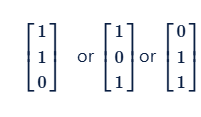</p><p>One of these vectors is then chosen randomly<strong>&nbsp;in each mini-batch.&nbsp;</strong>Let's say that, in some mini batch, the mask&nbsp;<img alt="Equation" data-latex="\alpha" src="https://latex.upgrad.com/render?formula=%5Calpha" style="vertical-align: middle;display: inline;">&nbsp;=&nbsp;<img alt="Equation" data-latex="\begin{bmatrix} 1\\ 1\\0 \end{bmatrix}" src="https://latex.upgrad.com/render?formula=%5Cbegin%7Bbmatrix%7D%201%5C%5C%201%5C%5C0%20%5Cend%7Bbmatrix%7D" style="vertical-align: middle;display: inline;">is chosen. Hence, the new (regularised) weight matrix will be:</p><p>&nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp;&nbsp;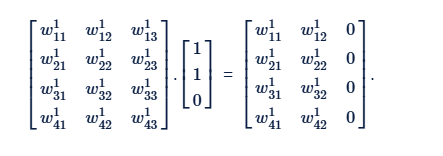<img alt="Equation" data-latex="\begin{bmatrix} w^1_{11} &amp; w^1_{12} &amp; w^1_{13}\\ w^1_{21} &amp; w^1_{22} &amp; w^1_{23}\\ w^1_{31} &amp; w^1_{32} &amp; w^1_{33}\\ w^1_{41} &amp; w^1_{42} &amp; w^1_{43}\\ \end{bmatrix}" src="https://latex.upgrad.com/render?formula=%5Cbegin%7Bbmatrix%7D%20w%5E1_%7B11%7D%20%26%20w%5E1_%7B12%7D%20%26%20w%5E1_%7B13%7D%5C%5C%20w%5E1_%7B21%7D%20%26%20w%5E1_%7B22%7D%20%26%20w%5E1_%7B23%7D%5C%5C%20w%5E1_%7B31%7D%20%26%20w%5E1_%7B32%7D%20%26%20w%5E1_%7B33%7D%5C%5C%20w%5E1_%7B41%7D%20%26%20w%5E1_%7B42%7D%20%26%20w%5E1_%7B43%7D%5C%5C%20%5Cend%7Bbmatrix%7D" style="vertical-align: middle;display: inline;"></p><p>As you can see, all the elements in the last column become zero. You can see the differences between the ANN without dropout and the ANN with dropout below. Adding a dropout layer essentially removes the links from the third neuron in the first layer to all the neurons in the next layer. The cross on the interconnections indicates that the interconnection has been removed.</p><p style="text-align: center;"><b id="docs-internal-guid-157ce595-7fff-dc24-13ad-f2e6086d12c3"><img data-height="384" data-width="1071" height="215.12605042016807" src="https://images.upgrad.com/d9f0dd4d-6330-478d-9a80-67a5ac3b75d3-Dropout1.jpg" width="600"></b></p><p><strong>Some important points&nbsp;to note regarding dropouts are:</strong></p><ul><li>Dropouts can be&nbsp;applied only to some layers of the network (in fact, that is a common practice - you choose some layer arbitrarily to apply dropouts to)</li><li>The mask <img alt="Equation" data-latex="\alpha" src="https://latex.upgrad.com/render?formula=%5Calpha" style="vertical-align: middle;display: inline;">&nbsp;is generated independently for each layer during&nbsp;feedforward, and the same mask&nbsp;is used in backpropagation</li><li>The mask&nbsp;changes with each minibatch/iteration and is randomly generated in each iteration (sampled from a&nbsp;Bernoulli with some&nbsp;<img alt="Equation" data-latex="p(1)=q" src="https://latex.upgrad.com/render?formula=p%281%29%3Dq" style="vertical-align: middle;display: inline;">)</li></ul><p>Why the dropout strategy works well is explained through the&nbsp;notion of a&nbsp;<strong>manifold</strong>. Manifold captures the observation that is in high dimensional spaces, the data points often actually lie in a <strong>lower-dimensional manifold</strong>. This is observed&nbsp;experimentally&nbsp;and can be understood intuitively as well.&nbsp;</p><p>For example, in a 50-dimensional space&nbsp;<img alt="Equation" data-latex="R^{50}" src="https://latex.upgrad.com/render?formula=R%5E%7B50%7D" style="vertical-align: middle;display: inline;">, it is likely that the data points actually lie in a much lower-dimensional subspace (manifold). The dropout strategy uses this fact to find a lower-dimensional solution to the problem.</p><p>Apart from reducing the complexity of the model, dropouts help us in another way.</p><p>Let's&nbsp;watch the next video to find out.</p></div></div>


As you learnt in the video above, dropouts help in symmetry breaking. There is an extremely high likelihood that communities will be created within neurons, which can restrict the neurons from learning independently. Hence, by setting a random set of the weights to zero in every iteration, this community/symmetry can be broken. Note that a different mini-batch is processed in every iteration in an epoch, and dropouts are applied to each mini-batch.

 

<div class="MuiBox-root css-1bi8ut6"><div class="text_component" data-testid="text-component"><p>Notice that after applying the mask&nbsp;<img alt="Equation" data-latex="\alpha" src="https://latex.upgrad.com/render?formula=%5Calpha" style="vertical-align: middle;display: inline;">, one of the columns of the weight matrix is set to zero. If the&nbsp;<img alt="Equation" data-latex="jth" src="https://latex.upgrad.com/render?formula=jth" style="vertical-align: middle;display: inline;">&nbsp;column is set to zero, it is equivalent to the contribution of the <img alt="Equation" data-latex="jth" src="https://latex.upgrad.com/render?formula=jth" style="vertical-align: middle;display: inline;"> neuron in the previous layer&nbsp;is zero. In other words, you cut off one neuron from the previous layer.&nbsp;</p><p>There are other ways to create the mask. One&nbsp;is to create a matrix which has 'q' percentage of the&nbsp;elements set to 1 and the rest 0. You can then multiply this matrix with the weight matrix element-wise to get the final weight matrix.</p><p>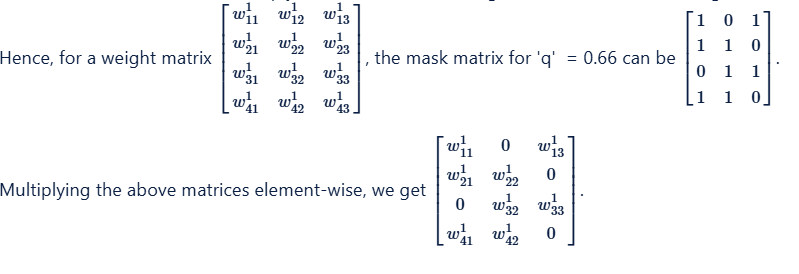</p><p>Visually, the matrix above can be shown as:</p><p><img data-height="405" data-width="1270" height="191.33858267716536" src="https://images.upgrad.com/234e92ed-54e2-4c77-838f-abece82cc3df-Neural network cross connection.jpg" width="600"></p><p>Well again, you need not worry about how to implement dropouts since you just need to write one simple line of code to add dropout in Keras.</p><p>You can write the following line of code:</p><pre># dropping out 20% neurons in a layer in Keras 
model.add(Dropout(0.2))
</pre><p></p><p dir="ltr">Some important points to note while implementing dropouts are as follows:</p><ol><li aria-level="1" dir="ltr"><p dir="ltr" role="presentation">&nbsp;Here, '0.2' is the <strong>probability of zeros</strong> and not ones.</p></li><li aria-level="1" dir="ltr"><p dir="ltr" role="presentation">This is one of the hyperparameters to be experimented with when building a neural network.</p></li><li aria-level="1" dir="ltr"><p dir="ltr" role="presentation">You do not apply dropout to the output layer.</p></li><li aria-level="1" dir="ltr"><p dir="ltr" role="presentation">The mask used here is a matrix.</p></li><li aria-level="1" dir="ltr"><p dir="ltr" role="presentation">Dropout is applied only during training, not while testing.</p></li></ol><p dir="ltr">Let’s now take a look at a <strong>demonstration </strong>of how dropout can be used as a good regularisation technique to help reduce overfitting in a model. For this, we will revisit the house price prediction example and build a neural network using Keras.</p><p dir="ltr">Here are some of the data points from the housing data set after feature transformation, as seen in the sessions on <strong>Feedforward Propagation</strong>.</p><p dir="ltr"><img data-height="460" data-width="1155" height="238.96103896103895" src="https://images.upgrad.com/629fa2d9-ff28-4146-a7f3-f52c1758bff1-housedata.jpg" width="600"></p><p dir="ltr">We will be using a different architecture to train the neural network for predicting house prices. The neural network architecture is shown below.</p><p dir="ltr">(<strong>Note</strong>: One neuron in each layer that is not connected to the previous layer represents the bias term for the next layer.)</p><p><img data-height="833" data-width="1600" height="312.375" src="https://images.upgrad.com/a5b285b9-14d1-455c-a2fa-5889d7634e25-Screenshot 2022-02-15 at 7.25.27 PM.png" width="600"></p><p dir="ltr">In the upcoming video, you will see how the training and validation performance changes with the use of the Dropout layer.</p></div></div>

# Batch Normalizations 

<div class="text_component" data-testid="text-component"><p dir="ltr">So far, you have understood how dropouts help regularise the neural network. Let's now take a look at one of the widely used techniques in training a neural network called <strong>batch normalisation.</strong></p><p>&nbsp;</p><p dir="ltr">It is generally a good idea to have your data on a common scale while training a neural network. Sometimes, when training a neural network, large activations might be produced. Different sizes of activations can result in unstable training behaviour. This is where ‘normalisation’ can be helpful. Normalisation is seen as an aid to the optimisation process. Commonly seen benefits are that fewer epochs are required to complete the network’s training process and sometimes, it avoids the neural network to get stuck during the training process. Let’s dive deeper into the batch normalisation layer.</p></div>

<div class="text_component" data-testid="text-component"><p>Before moving ahead, let's first clearly understand the problem batch normalisation is trying to solve.&nbsp;The feed forward equations&nbsp;for a single data point are given below:</p><p style="text-align: center;"><img alt="Equation" data-latex="h^1 = \sigma (W^1.x +b^1)" src="https://latex.upgrad.com/render?formula=h%5E1%20%3D%20%5Csigma%20%28W%5E1.x%20%2Bb%5E1%29" style="vertical-align: middle;display: inline;"></p><p style="text-align: center;"><img alt="Equation" data-latex="h^2 = \sigma (W^2.h^1 +b^2)" src="https://latex.upgrad.com/render?formula=h%5E2%20%3D%20%5Csigma%20%28W%5E2.h%5E1%20%2Bb%5E2%29" style="vertical-align: middle;display: inline;">&nbsp;=&nbsp;<img alt="Equation" data-latex="\sigma (W^2.(\sigma (W^1.x +b^1)) +b^2)" src="https://latex.upgrad.com/render?formula=%5Csigma%20%28W%5E2.%28%5Csigma%20%28W%5E1.x%20%2Bb%5E1%29%29%20%2Bb%5E2%29" style="vertical-align: middle;display: inline;"></p><p style="text-align: center;"><img alt="Equation" data-latex="h^3 = \sigma (W^3.h^2 +b^3)" src="https://latex.upgrad.com/render?formula=h%5E3%20%3D%20%5Csigma%20%28W%5E3.h%5E2%20%2Bb%5E3%29" style="vertical-align: middle;display: inline;">&nbsp;=&nbsp;<img alt="Equation" data-latex="\sigma (W^3.(\sigma (W^2.(\sigma (W^1.x +b^1)) +b^2)) +b^3)" src="https://latex.upgrad.com/render?formula=%5Csigma%20%28W%5E3.%28%5Csigma%20%28W%5E2.%28%5Csigma%20%28W%5E1.x%20%2Bb%5E1%29%29%20%2Bb%5E2%29%29%20%2Bb%5E3%29" style="vertical-align: middle;display: inline;"></p><p style="text-align: center;"><img alt="Equation" data-latex="h^4 = \sigma (W^4.h^3 +b^4)" src="https://latex.upgrad.com/render?formula=h%5E4%20%3D%20%5Csigma%20%28W%5E4.h%5E3%20%2Bb%5E4%29" style="vertical-align: middle;display: inline;"><img alt="Equation" data-latex="= \sigma (W^4.(​​ \sigma (W^3.(\sigma (W^2.(\sigma (W^1.x +b^1)) +b^2)) +b^3)) +b^4)" src="https://latex.upgrad.com/render?formula=%3D%20%5Csigma%20%28W%5E4.%28%E2%80%8B%E2%80%8B%20%5Csigma%20%28W%5E3.%28%5Csigma%20%28W%5E2.%28%5Csigma%20%28W%5E1.x%20%2Bb%5E1%29%29%20%2Bb%5E2%29%29%20%2Bb%5E3%29%29%20%2Bb%5E4%29" style="vertical-align: middle;display: inline;"></p><p>and so on, where&nbsp;<img alt="Equation" data-latex="\sigma" src="https://latex.upgrad.com/render?formula=%5Csigma" style="vertical-align: middle;display: inline;">&nbsp;is the activation function of the layer.</p><p>You can see that&nbsp;<img alt="Equation" data-latex="h^4" src="https://latex.upgrad.com/render?formula=h%5E4" style="vertical-align: middle;display: inline;">&nbsp;is a <strong>composite function</strong> of all the weights and biases from the previous layers, i.e. the output of subsequent layers depend on the previous weight matrices. Also, we can see that the interactions&nbsp;between the different weight matrices are non-linear.&nbsp;However, during backpropagation, the weights of various layers are updated independently of each other.</p><p>So, let’s watch the next video to learn about Batch Normalisation, which will help us solve this problem.&nbsp;</p></div>

<div class="text_component" data-testid="text-component"><p><strong>Batch normalisation</strong> is performed on the output of the layers of each batch,&nbsp;<img alt="Equation" data-latex="H^l" src="https://latex.upgrad.com/render?formula=H%5El" style="vertical-align: middle;display: inline;">. It is essentially normalising the matrix&nbsp;<img alt="Equation" data-latex="H^l" src="https://latex.upgrad.com/render?formula=H%5El" style="vertical-align: middle;display: inline;"> across all data points in the batch. Each vector in <img alt="Equation" data-latex="H^l" src="https://latex.upgrad.com/render?formula=H%5El" style="vertical-align: middle;display: inline;">&nbsp;is normalised by the mean vector&nbsp;<img alt="Equation" data-latex="\mu" src="https://latex.upgrad.com/render?formula=%5Cmu" style="vertical-align: middle;display: inline;">&nbsp;and the standard deviation&nbsp;vector&nbsp;<img alt="Equation" data-latex="\hat \sigma" src="https://latex.upgrad.com/render?formula=%5Chat%20%5Csigma" style="vertical-align: middle;display: inline;">&nbsp;computed across a batch.</p><p>The image shows the batch normalisation process for a layer <img alt="Equation" data-latex="l" src="https://latex.upgrad.com/render?formula=l" style="vertical-align: middle;display: inline;">. Each column in the matrix <img alt="Equation" data-latex="H^l" src="https://latex.upgrad.com/render?formula=H%5El" style="vertical-align: middle;display: inline;">&nbsp;represents the output vector of layer <img alt="Equation" data-latex="l" src="https://latex.upgrad.com/render?formula=l" style="vertical-align: middle;display: inline;">, <img alt="Equation" data-latex="h^l" src="https://latex.upgrad.com/render?formula=h%5El" style="vertical-align: middle;display: inline;">, for each of the <img alt="Equation" data-latex="m" src="https://latex.upgrad.com/render?formula=m" style="vertical-align: middle;display: inline;">&nbsp;data points in the batch. We compute the&nbsp;<img alt="Equation" data-latex="\mu" src="https://latex.upgrad.com/render?formula=%5Cmu" style="vertical-align: middle;display: inline;">&nbsp;and the&nbsp;<img alt="Equation" data-latex="\hat \sigma" src="https://latex.upgrad.com/render?formula=%5Chat%20%5Csigma" style="vertical-align: middle;display: inline;">&nbsp;vectors which represent the mean output from layer <img alt="Equation" data-latex="l" src="https://latex.upgrad.com/render?formula=l" style="vertical-align: middle;display: inline;">&nbsp;across all points in the batch'. We then normalise each column of the matrix&nbsp;<img alt="Equation" data-latex="H^l" src="https://latex.upgrad.com/render?formula=H%5El" style="vertical-align: middle;display: inline;">&nbsp;using&nbsp;<img alt="Equation" data-latex="\mu" src="https://latex.upgrad.com/render?formula=%5Cmu" style="vertical-align: middle;display: inline;">&nbsp;and&nbsp;<img alt="Equation" data-latex="\hat \sigma" src="https://latex.upgrad.com/render?formula=%5Chat%20%5Csigma" style="vertical-align: middle;display: inline;">.</p><p><img alt="Batchnormalisation" src="https://cdn.upgrad.com/UpGrad/temp/2cbe8f96-1f9c-4cc5-86b4-79d37a3bc06f/batchnorm.png"></p><p>Hence, if a particular layer&nbsp;<img alt="Equation" data-latex="l" src="https://latex.upgrad.com/render?formula=l" style="vertical-align: middle;display: inline;">&nbsp;&nbsp;has 5 neurons, we will have&nbsp;<img alt="Equation" data-latex="H^l" src="https://latex.upgrad.com/render?formula=H%5El" style="vertical-align: middle;display: inline;">&nbsp;of the shape (5, m) where 'm' is the batch size and&nbsp;<img alt="Equation" data-latex="\mu" src="https://latex.upgrad.com/render?formula=%5Cmu" style="vertical-align: middle;display: inline;">&nbsp;&amp;&nbsp;<img alt="Equation" data-latex="\hat \sigma" src="https://latex.upgrad.com/render?formula=%5Chat%20%5Csigma" style="vertical-align: middle;display: inline;">&nbsp;vectors of shape (5,1). The first element of&nbsp;<img alt="Equation" data-latex="\mu" src="https://latex.upgrad.com/render?formula=%5Cmu" style="vertical-align: middle;display: inline;">&nbsp;(<img alt="Equation" data-latex="\mu _1" src="https://latex.upgrad.com/render?formula=%5Cmu%20_1" style="vertical-align: middle;display: inline;">) is the mean of the outputs of the first neuron for all the 'm' data points, the second element&nbsp;<img alt="Equation" data-latex="\mu _2" src="https://latex.upgrad.com/render?formula=%5Cmu%20_2" style="vertical-align: middle;display: inline;"> is the mean of the outputs of the second neuron for all the 'm ' data points and so on. Similarly, we get a vector&nbsp;<img alt="Equation" data-latex="\hat \sigma" src="https://latex.upgrad.com/render?formula=%5Chat%20%5Csigma" style="vertical-align: middle;display: inline;">&nbsp;as the standard deviation of the outputs of the five neurons across the m points. The&nbsp;normalisation step is then:</p><p style="text-align: center;"><img alt="Equation" data-latex="H^l = \frac{H^l - \mu }{\hat\sigma}" src="https://latex.upgrad.com/render?formula=H%5El%20%3D%20%5Cfrac%7BH%5El%20-%20%5Cmu%20%7D%7B%5Chat%5Csigma%7D"></p><p>This step is performed by <strong>broadcasting</strong>&nbsp;<img alt="Equation" data-latex="\mu" src="https://latex.upgrad.com/render?formula=%5Cmu" style="vertical-align: middle;display: inline;">&nbsp;and&nbsp;<img alt="Equation" data-latex="\hat \sigma" src="https://latex.upgrad.com/render?formula=%5Chat%20%5Csigma" style="vertical-align: middle;display: inline;">. The final&nbsp;<img alt="Equation" data-latex="H^l" src="https://latex.upgrad.com/render?formula=H%5El" style="vertical-align: middle;display: inline;">&nbsp;after batch normalisation is shown on the left side of the image above.</p><p>Let’s try this out for the simple model built for the housing data set. The architecture is given below to refresh your memory</p><p><img alt="NN network" src="https://images.upgrad.com/3c0e5ad3-0cba-41c5-b730-f3783a2773d0-NN%20network.jpg"></p><p>We have included six examples from the normalised housing data set below. We will send a batch of six input observations to be fed into the neural network.</p><p><img alt="Housing dataset" src="https://images.upgrad.com/2abcd8d2-5097-4774-8c83-33658b354ee6-House%20price.jpg"></p><p>Suppose there is a batch normalization layer after the first hidden layer. The model in Keras would look like this:</p><div class="code-snippet-container" data-lang="python" id="code-snippet-cke_170200"><div class="code" contenteditable="false"><pre style="margin: 0; line-height: 125%;"><span></span>model <span style="color: #333333">=</span> keras<span style="color: #333333">.</span>Sequential(
    [
        keras<span style="color: #333333">.</span>layers<span style="color: #333333">.</span>Input(shape<span style="color: #333333">=</span>(X_train<span style="color: #333333">.</span>shape[<span style="color: #333333">-</span><span style="color: #0000DD; font-weight: bold">1</span>],)),
        keras<span style="color: #333333">.</span>layers<span style="color: #333333">.</span>Dense(
            <span style="color: #0000DD; font-weight: bold">2</span>, activation<span style="color: #333333">=</span><span style="background-color: #fff0f0">"sigmoid"</span>
        ),
        keras<span style="color: #333333">.</span>layers<span style="color: #333333">.</span>BatchNormalization(),
        keras<span style="color: #333333">.</span>layers<span style="color: #333333">.</span>Dense(<span style="color: #0000DD; font-weight: bold">1</span>, activation<span style="color: #333333">=</span><span style="background-color: #fff0f0">"linear"</span>)
    ]
)
</pre></div></div><p>We will now see how batch normalization is performed on the output of the hidden layer before it is given as the input to the next (in this case, output) layer. Let’s focus on the first neuron of the hidden layer. We know that the output value, i.e., the activation it obtains from the input is as follows:&nbsp;<img alt="Equation" data-latex="h_{1}^{1}=\sigma (w_{11}^{1}x_{1}+w_{12}^{1}x_{2}+b_{1}^{1})" src="https://latex.upgrad.com/render?formula=h_%7B1%7D%5E%7B1%7D%3D%5Csigma%20%28w_%7B11%7D%5E%7B1%7Dx_%7B1%7D%2Bw_%7B12%7D%5E%7B1%7Dx_%7B2%7D%2Bb_%7B1%7D%5E%7B1%7D%29" style="vertical-align: middle;display: inline;">&nbsp;&nbsp;where,&nbsp;<img alt="Equation" data-latex="\sigma" src="https://latex.upgrad.com/render?formula=%5Csigma" style="vertical-align: middle;display: inline;">&nbsp;is the sigmoid activation function (please refer to the image of the model given above for the values of weights and biases).</p><p><img alt="House data normalised" src="https://images.upgrad.com/2bc5d041-eacb-40e6-b34a-0cbb7500b7ac-Houseimage2.jpg"></p><p dir="ltr">The <img alt="Equation" data-latex="\mu" src="https://latex.upgrad.com/render?formula=%5Cmu" style="vertical-align: middle;display: inline;">(mean) and <img alt="Equation" data-latex="\sigma" src="https://latex.upgrad.com/render?formula=%5Csigma" style="vertical-align: middle;display: inline;">(standard deviation) are calculated from the six values of the output of the first neuron in the hidden layer, i.e., <img alt="Equation" data-latex="h^{l}_{1}" src="https://latex.upgrad.com/render?formula=h%5E%7Bl%7D_%7B1%7D" style="vertical-align: middle;display: inline;">, and then, we performed&nbsp;<img alt="Equation" data-latex="h^{l}=\frac{h^{l}-\mu }{ \hat{\sigma }}" src="https://latex.upgrad.com/render?formula=h%5E%7Bl%7D%3D%5Cfrac%7Bh%5E%7Bl%7D-%5Cmu%20%7D%7B%20%5Chat%7B%5Csigma%20%7D%7D" style="vertical-align: middle;display: inline;">to obtain the new output values to be fed to the next layer as the input. The same operation can be performed separately on the second neuron of the hidden layer. Remember that we have defined the batch size as 6. These values will change as per the batch size considered.</p><p dir="ltr">This is how batch normalisation is performed on the output of each node in a layer. This normalised output is then fed as the input to the next layer. Batch normalisation is generally performed on all the layers except the output layer.</p><p dir="ltr">However, there is one small problem: How do we perform batch normalisation during test time?&nbsp;Test data points are&nbsp;fed forward one at a time, and there are no&nbsp;'batches' during test</p><p dir="ltr">time.&nbsp;Thus, we do not&nbsp;have any&nbsp;<img alt="Equation" data-latex="\mu" src="https://latex.upgrad.com/render?formula=%5Cmu" style="vertical-align: middle;display: inline;"> and&nbsp;<img alt="Equation" data-latex="\sigma" src="https://latex.upgrad.com/render?formula=%5Csigma" style="vertical-align: middle;display: inline;"> to normalise each test data point with. So, we take some sort of an average, i.e., the&nbsp;average&nbsp;of the&nbsp;<img alt="Equation" data-latex="\mu" src="https://latex.upgrad.com/render?formula=%5Cmu" style="vertical-align: middle;display: inline;">'s<strong>&nbsp;</strong>&nbsp;and&nbsp;<img alt="Equation" data-latex="\sigma" src="https://latex.upgrad.com/render?formula=%5Csigma" style="vertical-align: middle;display: inline;">'s&nbsp;of the different batches of the&nbsp;training&nbsp;set.</p><p dir="ltr">To get an intuition behind how batch normalisation solves the problem of decoupling the weight interactions and improves the training procedure, let's reiterate why&nbsp;the normalisation of the input data&nbsp;works in the first place.&nbsp;The answer is that&nbsp;the loss function contours change&nbsp;after normalisation, as shown in the figure below, and it is easier to find the minimum of&nbsp;the contours in the image on the right than that of the contours in the image on the left.<b>&nbsp;</b></p><p dir="ltr"><img alt="normalisation" src="https://cdn.upgrad.com/UpGrad/temp/8dcf2a28-66c5-4c19-a921-2a45b987337b/Contours.png"></p><p dir="ltr">&nbsp;Note that the batch normalization process can also be applied to the cumulative input vector into the layer,&nbsp;<img alt="Equation" data-latex="Z^{l}" src="https://latex.upgrad.com/render?formula=Z%5E%7Bl%7D" style="vertical-align: middle;display: inline;">, instead of&nbsp; <img alt="Equation" data-latex="H^{l}" src="https://latex.upgrad.com/render?formula=H%5E%7Bl%7D" style="vertical-align: middle;display: inline;">. These are different heuristics, so you need not worry about them. This is because&nbsp;deep learning frameworks such as Keras use&nbsp;empirically proven techniques; you just need to write a simple line of code.</p><p dir="ltr">Libraries such as Keras use a slightly different form of batch normalization. We transform the equations given above as:</p><p dir="ltr"><b><img data-height="112" data-width="394" height="112" src="https://images.upgrad.com/12e850ec-63dd-4b72-9911-c25944bf04cf-3formula.jpg" width="394"></b></p><p>where, the constant&nbsp;<img alt="Equation" data-latex="\epsilon" src="https://latex.upgrad.com/render?formula=%5Cepsilon" style="vertical-align: middle;display: inline;"> ensures&nbsp;that the denominator does not become zero&nbsp;(when the variance is 0). The constants&nbsp;<img alt="Equation" data-latex="\gamma" src="https://latex.upgrad.com/render?formula=%5Cgamma" style="vertical-align: middle;display: inline;">&nbsp;and <img alt="Equation" data-latex="\beta" src="https://latex.upgrad.com/render?formula=%5Cbeta" style="vertical-align: middle;display: inline;">&nbsp;are&nbsp;hyperparameters. In Keras, batch normalisation is implemented as follows:</p><div class="code-snippet-container" data-lang="python" id="code-snippet-cke_170202"><div class="code" contenteditable="false"><pre style="margin: 0; line-height: 125%;"><span></span><span style="color: #888888">#Parameters used in batch normalisation.</span>
<span style="color: #888888">#In case not mentioned, these values will take the default value.</span>
model<span style="color: #333333">.</span>add(BatchNormalization(axis<span style="color: #333333">=-</span><span style="color: #0000DD; font-weight: bold">1</span>, epsilon<span style="color: #333333">=</span><span style="color: #6600EE; font-weight: bold">0.001</span>, 
beta_initializer<span style="color: #333333">=</span><span style="background-color: #fff0f0">'zeros'</span>, 
gamma_initializer<span style="color: #333333">=</span><span style="background-color: #fff0f0">'ones'</span>))
</pre></div></div><p>The ‘axis=-1’ specifies that the normalisation should happen across the rows.</p><p dir="ltr"><strong>An example of how you can add the layer in the Keras architecture is given below.</strong></p><div class="code-snippet-container" data-lang="python" id="code-snippet-cke_170201"><div class="code" contenteditable="false"><pre style="margin: 0; line-height: 125%;"><span></span>model <span style="color: #333333">=</span> keras<span style="color: #333333">.</span>Sequential([
    keras<span style="color: #333333">.</span>layers<span style="color: #333333">.</span>Input(shape<span style="color: #333333">=</span>(<span style="color: #0000DD; font-weight: bold">784</span>,)),
    keras<span style="color: #333333">.</span>layers<span style="color: #333333">.</span>Flatten(),
    keras<span style="color: #333333">.</span>layers<span style="color: #333333">.</span>Dense(<span style="color: #0000DD; font-weight: bold">128</span>, activation<span style="color: #333333">=</span>tf<span style="color: #333333">.</span>nn<span style="color: #333333">.</span>relu),
    keras<span style="color: #333333">.</span>layers<span style="color: #333333">.</span>Dense(<span style="color: #0000DD; font-weight: bold">128</span>, activation<span style="color: #333333">=</span>tf<span style="color: #333333">.</span>nn<span style="color: #333333">.</span>relu),
    keras<span style="color: #333333">.</span>layers<span style="color: #333333">.</span>Dense(<span style="color: #0000DD; font-weight: bold">128</span>, activation<span style="color: #333333">=</span>tf<span style="color: #333333">.</span>nn<span style="color: #333333">.</span>relu),
    keras<span style="color: #333333">.</span>layers<span style="color: #333333">.</span>BatchNormalization(),
    keras<span style="color: #333333">.</span>layers<span style="color: #333333">.</span>Dense(<span style="color: #0000DD; font-weight: bold">10</span>, activation<span style="color: #333333">=</span>tf<span style="color: #333333">.</span>nn<span style="color: #333333">.</span>softmax)
])
</pre></div></div><p>You can play around with the model architecture along with the batch normalization layer in the <strong>MNIST_keras</strong> notebook provided in the earlier segment. And then we can test the model performance. Just add the batch normalization code after the third layer as shown in the above code and run the model. Here, the batch normalization is performed in the third layer and then output is fed to the next layer.</p><p><strong>In this example, the working principle of batch normalization is as follows:</strong></p><p dir="ltr">We can see that the dense hidden layer has 128 neurons. Suppose a batch size of 64 is defined for training the model. This means that 64 input examples are supplied at once to the neural network; hence, there will be 64 outputs of the third dense hidden layer. This means that each of the 128 neurons will have 64 outputs. For each neuron, the mean and standard deviation is computed using its corresponding 64 outputs and then normalized. The updated outputs are then fed as inputs to the next layer.</p><p><strong>Note</strong>: Batch normalization might not be very useful in the neural networks that we have learnt about so far. Batch normalization is usually used in large architectures that train over a variety of data and solve complex problems. You will understand the importance of the batch normalization layer when you are introduced to the concept of Convolutional Neural Networks in another module.&nbsp;</p></div>